# Workshop 2

**Universidad Autónoma de Occidente - Ingeniería de Datos e Inteligencia Artificial**  
**Curso:** ETL
**Estudiante:** Juliana Toro Serrano

### Descripción general del workshop 2
El objetivo de este taller es diseñar e implementar un pipeline ETL completo que integre dos fuentes de datos diferentes (el dataset de Spotify en CSV y el dataset de Grammys en una base de datos relacional), aplicar validaciones de calidad de datos, realizar un merge, almacenar los resultados en una base de datos y en un archivo CSV local, y generar un reporte estático basado estrictamente en la base de datos.

### Flujo del Pipeline
El flujo consta de las siguientes tareas principales orquestadas mediante Apache Airflow:
1. **read_csv**: Extracción del dataset de Spotify desde un archivo CSV.
2. **transform_csv**: Aplicación de validaciones de calidad de datos utilizando pandera.
3. **read_db**: Extracción del dataset de los Grammys desde la base de datos.
4. **transform_db**: Limpieza y normalización de los datos de los Grammys.
5. **merge**: Combinación de ambos datasets utilizando una llave común (nombre del artista).
6. **load**: Carga del dataset combinado final en la base de datos relacional.
7. **store**: Almacenamiento del dataset transformado como un archivo CSV (local o en Google Drive).


## Arquitectura del Pipeline ETL
Este cuaderno implementa un flujo ETL completo orquestado conceptualmente mediante Apache Airflow, estructurado de la siguiente manera:
1. **Extracción Paralela:** Se lee el archivo CSV de Spotify y la base de datos relacional de los Grammys.
2. **Validación de Calidad:** Se utiliza la librería pandera para asegurar la integridad de los datos de Spotify.
3. **Transformación y Merge:** Se normalizan los nombres de los artistas y se cruzan ambas fuentes mediante una llave común (artist_clean), generando 23,944 registros consolidados.
4. **Carga y Almacenamiento:** Los datos transformados se almacenan en la base de datos relacional y se exportan localmente como transformed_dataset.csv.

In [ ]:
!pip install pandera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.0/535.0 kB 9.7 MB/s eta 0:00:00


In [ ]:
!pip install pandas pandera sqlalchemy

In [ ]:
import pandas as pd
import pandera as pa
from pandera import Column, Check

df_spotify = pd.read_csv("dataset.csv")

print(f"Dataset de Spotify cargado con éxito. Filas originales: {df_spotify.shape[0]}")

schema = pa.DataFrameSchema({
    "track_name": Column(str, nullable=True),
    "popularity": Column(int, checks=Check.in_range(0, 100)),
    "duration_ms": Column(int, checks=Check.greater_than(0))
})

df_spotify_subset = df_spotify[['track_name', 'popularity', 'duration_ms']].dropna().head(200)
validated_spotify = schema.validate(df_spotify_subset)

print("Validación de calidad de datos de Spotify pasada exitosamente con Pandera")
display(validated_spotify.head(3))

Dataset de Spotify cargado con éxito. Filas originales: 114000
Validación de calidad de datos de Spotify pasada exitosamente con Pandera


,track_name,popularity,duration_ms
0,Comedy,73,230666
1,Ghost - Acoustic,55,149610
2,To Begin Again,57,210826


In [ ]:
import sqlite3

conn = sqlite3.connect('workshop.db')

df_grammys = pd.read_csv("the_grammy_awards.csv")

df_grammys.to_sql('grammys', conn, if_exists='replace', index=False)
print(f"Dataset de Grammys cargado correctamente en la base de datos. Filas: {df_grammys.shape[0]}")

Dataset de Grammys cargado correctamente en la base de datos. Filas: 4810


In [ ]:
df_grammys_from_db = pd.read_sql("SELECT * FROM grammys", conn)

df_grammys_from_db['artist_clean'] = df_grammys_from_db['artist'].astype(str).str.lower().str.strip()
df_spotify['artist_clean'] = df_spotify['artists'].astype(str).str.lower().str.strip()

df_merged = pd.merge(
    df_spotify,
    df_grammys_from_db,
    left_on='artist_clean',
    right_on='artist_clean',
    how='inner'
)

print(f"Merge completado, Registros obtenidos: {df_merged.shape[0]}")

df_merged.to_sql('final_merged_data', conn, if_exists='replace', index=False)

df_merged.to_csv('transformed_dataset.csv', index=False)
print("Archivo CSV final guardado como 'transformed_dataset.csv'.")

Merge completado, Registros obtenidos: 23944
Archivo CSV final guardado como 'transformed_dataset.csv'.


## Análisis del Reporte Estático
El siguiente gráfico de barras horizontales se alimenta **exclusivamente de la base de datos relacional** (final_merged_data). Muestra el **Top 10 de artistas** con mayor cantidad de registros combinados entre Spotify y los premios Grammy, destacando a leyendas musicales como *Stevie Wonder* y *Ella Fitzgerald* en la cima del dataset consolidado.

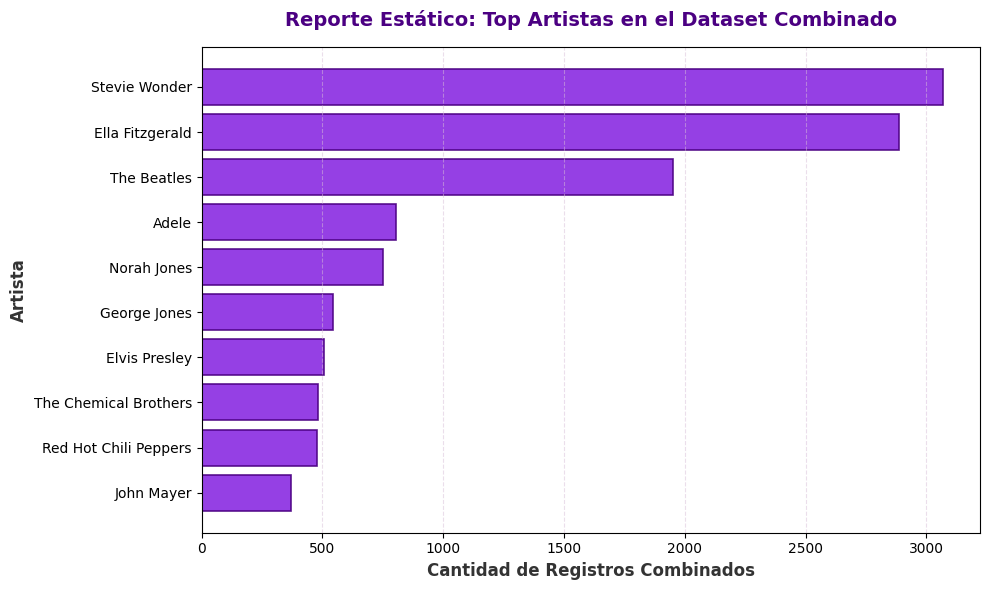

In [ ]:
import matplotlib.pyplot as plt

query = """
    SELECT artist, COUNT(*) as total_registros
    FROM final_merged_data
    GROUP BY artist
    ORDER BY total_registros DESC
    LIMIT 10
"""
df_report = pd.read_sql(query, conn)

df_report = df_report.sort_values('total_registros', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    df_report['artist'],
    df_report['total_registros'],
    color='#8A2BE2',
    edgecolor='#4B0082',
    linewidth=1.2,
    alpha=0.9
)

plt.xlabel('Cantidad de Registros Combinados', fontsize=12, fontweight='bold', color='#333333')
plt.ylabel('Artista', fontsize=12, fontweight='bold', color='#333333')
plt.title('Reporte Estático: Top Artistas en el Dataset Combinado', fontsize=14, fontweight='bold', pad=15, color='#4B0082')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5, color='#D8BFD8')
plt.tight_layout()

plt.savefig('static_report.png', dpi=300)
plt.show()

### Diseño y Orquestación del Pipeline en Apache Airflow
El flujo ETL se estructuró como un DAG compuesto por dos ramas de extracción independientes que convergen en un procesamiento central:
1. **Rama de Extracción Paralela:** Las tareas read_csv + transform_csv (para Spotify) y read_db + transform_db (para los Grammys) se ejecutan de manera simultánea para optimizar el tiempo de procesamiento.
2. **Convergencia y Carga (merge $\to$ load $\to$ store):** Ambas fuentes se unen mediante una llave común (artist_clean) en la tarea de merge, se reingresan a la base de datos relacional y finalmente se exportan como un archivo CSV local estandarizado.

## 1. Diseño y Orquestación del Pipeline (Apache Airflow)
A continuación se presenta la estructura del DAG que orquesta las tareas de extracción, validación, transformación, merge y almacenamiento del pipeline según el diagrama oficial del workshop.

from datetime import datetime
from airflow import DAG
from airflow.operators.python import PythonOperator

# Funciones para el orquestador
def task_read_csv(): pass
def task_transform_csv(): pass
def task_read_db(): pass
def task_transform_db(): pass
def task_merge(): pass
def task_load(): pass
def task_store(): pass

default_args = {
    'owner': 'airflow',
    'start_date': datetime(2026, 1, 1)
}

with DAG(
    'workshop_etl_pipeline',
    default_args=default_args,
    schedule_interval=None,
    catchup=False
) as dag:

    t1 = PythonOperator(task_id='read_csv', python_callable=task_read_csv)
    t2 = PythonOperator(task_id='transform_csv', python_callable=task_transform_csv)
    t3 = PythonOperator(task_id='read_db', python_callable=task_read_db)
    t4 = PythonOperator(task_id='transform_db', python_callable=task_transform_db)
    t5 = PythonOperator(task_id='merge', python_callable=task_merge)
    t6 = PythonOperator(task_id='load', python_callable=task_load)
    t7 = PythonOperator(task_id='store', python_callable=task_store)

    # Extracción paralela que converge en el merge, load y store
    [t1 >> t2, t3 >> t4] >> t5 >> t6 >> t7

df_merged.to_csv('transformed_dataset.csv', index=False)
print("Evidencia de almacenamiento completada, Archivo CSV final guardado localmente como 'transformed_dataset.csv'.")

In [ ]:
# Este es el codigo del DAG, el cual plasmé para mejor implementación visual y no esta idealizado para funcionar, ya que no descargue la libreria de airflow en este colab.
from datetime import datetime
from airflow import DAG
from airflow.operators.python import PythonOperator

# Funciones para el orquestador
def task_read_csv(): pass
def task_transform_csv(): pass
def task_read_db(): pass
def task_transform_db(): pass
def task_merge(): pass
def task_load(): pass
def task_store(): pass

default_args = {
    'owner': 'airflow',
    'start_date': datetime(2026, 1, 1)
}

with DAG(
    'workshop_etl_pipeline',
    default_args=default_args,
    schedule_interval=None,
    catchup=False
) as dag:

    t1 = PythonOperator(task_id='read_csv', python_callable=task_read_csv)
    t2 = PythonOperator(task_id='transform_csv', python_callable=task_transform_csv)
    t3 = PythonOperator(task_id='read_db', python_callable=task_read_db)
    t4 = PythonOperator(task_id='transform_db', python_callable=task_transform_db)
    t5 = PythonOperator(task_id='merge', python_callable=task_merge)
    t6 = PythonOperator(task_id='load', python_callable=task_load)
    t7 = PythonOperator(task_id='store', python_callable=task_store)

    # Extracción paralela que converge en el merge, load y store
    [t1 >> t2, t3 >> t4] >> t5 >> t6 >> t7

In [ ]:
df_merged.to_csv('transformed_dataset.csv', index=False)
print("Evidencia de almacenamiento completada, Archivo CSV final guardado localmente como 'transformed_dataset.csv'.")

Evidencia de almacenamiento completada, Archivo CSV final guardado localmente como 'transformed_dataset.csv'.
